# GaMoE: Step-by-Step Interactive Workflow on Real Hippocampal Data
## Microcircuit Dissection, Manifold Inspection, and Event-Level Expert Attribution

This notebook steps through the complete analytical and geometric pipeline:
1. **Split & Cross-Validation Visualizer**: Plots the hierarchical 4-way data partition (UMAP fit, Q-prior, Training, Testing) and the 10-fold CV matrix.
2. **4D Manifold Geometry Decomposition**: Visualizes all 4 pairwise UMAP projection combinations ($U_1$ vs $U_2$, $U_3$ vs $U_4$, $U_1$ vs $U_3$, $U_2$ vs $U_4$).
3. **Manifold Population Weight Overlays**: Plots the 11 cell-type mean weights across the manifold coordinates.
4. **Gaussian Density Prior Gates**: Visualizes the density-derived gate weights $g_j(\mathbf{u})$ for each of the 11 experts across the manifold.
5. **Interactive Single-Ripple Expert Deconstruction**: An interactive widget (`ipywidgets`) allowing you to select any individual ripple $i$, display its true ripple frequency and amplitude, plot where each individual expert $f_j(w_j)$ projects into the UMAP cloud, show the gate magnitude $g_j(\mathbf{u})$ assigned to each expert, and display the final combined prediction $\hat{\mathbf{u}}_i = \sum_j g_j f_j$.
6. **Interactive Single-Ripple Ablation Simulator**: For the selected ripple event, interactively test any ablation condition (`gate` drop or `shuffle`), observing how the prediction vector shifts across the UMAP cloud color-coded by ripple frequency or amplitude.

In [1]:
# ==============================================================================
# Cell 1: Environment, Dependencies, and Directory Setup
# ==============================================================================
import os
import re
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy.io import loadmat

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor

import ipywidgets as widgets
from IPython.display import display

# Seeds
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sns.set_theme(style="whitegrid")
%matplotlib inline

# File paths
project_dir = "/home/melisamc/Documents/ripple_composition"
split_root  = os.path.join(project_dir, "experiments_filt_ripples/splits_priors")
out_root    = os.path.join(project_dir, "experiments_filt_ripples/gamoe_CelltypeDeepSup")
os.makedirs(out_root, exist_ok=True)

# Custom colormap matching manuscript figures
custom_green = LinearSegmentedColormap.from_list(
    "custom_green", ["#f1f4ec", "#d6e0c4", "#b5c796", "#86a25f", "#5f7f34"], N=256
)

print(f"Device: {device}")
print(f"Reading splits from: {split_root}")

Device: cpu
Reading splits from: /home/melisamc/Documents/ripple_composition/experiments_filt_ripples/splits_priors


## Step 1: Population Structure & Pre-computed Fold Loading

We load:
* **11 CA1 Cell Types**: `DeepPC`, `DeepPV`, `DeepBist`, `SupPC`, `SupPV`, `SupBist`, `DeepCCK`, `DeepAxoAxonic`, `SupCCK`, `SupAxoAxonic`, `OriensInt`[cite: 3].
* **4D UMAP Manifold Coordinates**: $U_1, U_2, U_3, U_4$[cite: 3].
* **Covariates**: Peak frequency ($f$, Hz) and z-scored envelope amplitude ($a$)[cite: 3].

In [2]:
# ==============================================================================
# Cell 2: Load Fold 1 Data & Covariates
# ==============================================================================
FULL_FEATS = [
    "DeepPyr", "DeepPV", "DeepBist", "SupPyr", "SupPV", "SupBist",
    "DeepCCK", "DeepAxoAxonic", "SupCCK", "SupAxoAxonic", "OriensInt"
]
N_EXPERTS = len(FULL_FEATS)
LATENT_DIM = 4

# Load Fold 1 as the primary interactive exploration fold
fold_num = 1
fold_dir = os.path.join(split_root, f"fold_{fold_num}")
input_type = "weights"
prefix = "weights" if input_type == "weights" else "frTable"

# Raw inputs and targets
X_train_df = pd.read_csv(os.path.join(fold_dir, f"{prefix}_train.csv"))[FULL_FEATS]
X_test_df  = pd.read_csv(os.path.join(fold_dir, f"{prefix}_test_eval.csv"))[FULL_FEATS]

U_train_df = pd.read_csv(os.path.join(fold_dir, "umap4_train.csv"))
U_test_df  = pd.read_csv(os.path.join(fold_dir, "umap4_test_eval.csv"))

# Prior split
prior_df   = pd.read_csv(os.path.join(fold_dir, f"{prefix}_prior.csv"))[FULL_FEATS]
U_prior_df = pd.read_csv(os.path.join(fold_dir, "umap4_prior.csv"))

X_train = X_train_df.to_numpy()
X_test  = X_test_df.to_numpy()
U_train = U_train_df.to_numpy()
U_test  = U_test_df.to_numpy()
W_prior = prior_df.to_numpy()
U_prior = U_prior_df.to_numpy()

# Load covariates for the test evaluation set
def load_cov_vector(fold_dir, candidates):
    for base in candidates:
        p_csv = os.path.join(fold_dir, base + ".csv")
        if os.path.exists(p_csv):
            return pd.read_csv(p_csv).iloc[:, 0].to_numpy()
        p_mat = os.path.join(fold_dir, base + ".mat")
        if os.path.exists(p_mat):
            m = loadmat(p_mat)
            keys = [k for k in m.keys() if not k.startswith("__")]
            return np.asarray(m[keys[0]]).squeeze()
    raise FileNotFoundError(f"Missing covariate file for {candidates}")

freq_test = load_cov_vector(fold_dir, ["freq_test_eval", "freq_eval_test", "freq_test", "freq"])
amp_test  = load_cov_vector(fold_dir, ["amp_test_eval", "amp_eval_test", "amp_test", "amp"])

print(f"Loaded Fold {fold_num}:")
print(f"  Prior Set: {W_prior.shape[0]} ripples | Train Set: {X_train.shape[0]} ripples | Test Set: {X_test.shape[0]} ripples")

Loaded Fold 1:
  Prior Set: 7132 ripples | Train Set: 24964 ripples | Test Set: 3567 ripples


## Step 2: Visualization of the Data Partition & Cross-Validation Architecture

According to the study design, data is strictly separated into non-overlapping blocks to prevent coordinate leakage[cite: 3]:
* **40% UMAP Fit**: Used solely to construct the 4D manifold[cite: 3].
* **20% Q-Prior**: Used to estimate the spatial Gaussian density parameters $(\boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)$[cite: 3].
* **30% Training**: Used to optimize the bottleneck expert parameters[cite: 3].
* **10% Test Evaluation**: Completely held-out set to benchmark reconstruction and ablations[cite: 3].

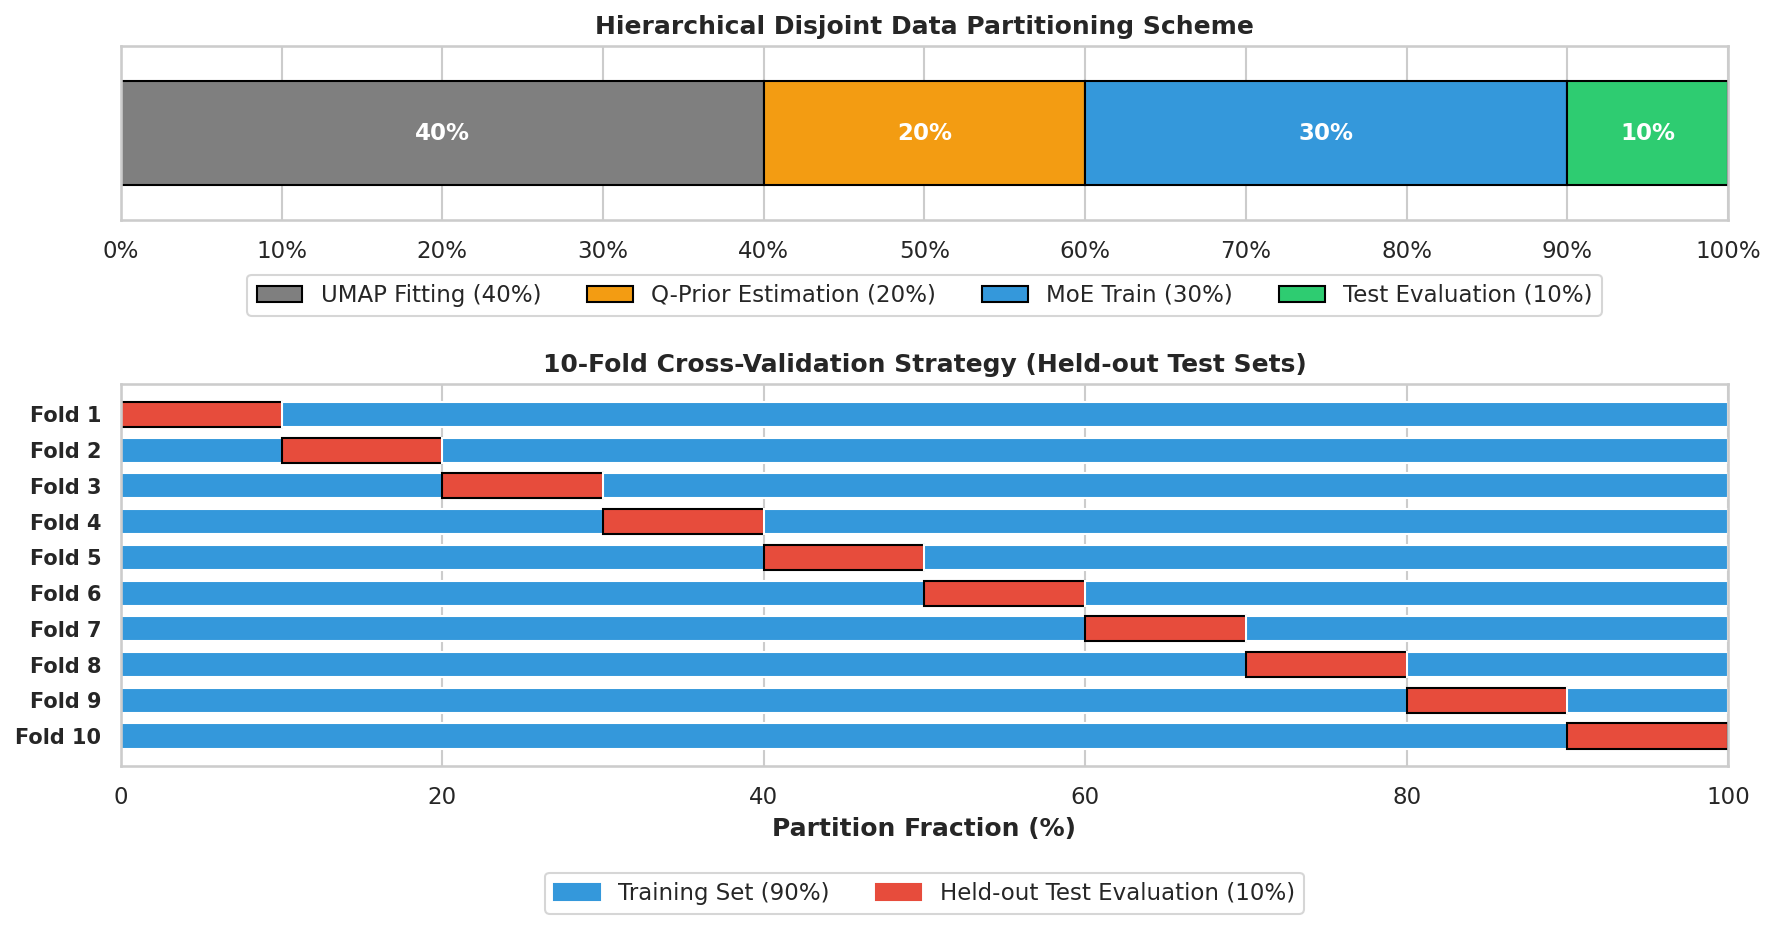

In [3]:
# ==============================================================================
# Cell 3: Plot Data Partitioning and 10-Fold Cross-Validation Matrix
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6.5), gridspec_kw={'height_ratios': [1, 2.2]}, dpi=150)

# 1. 4-Way Disjoint Split Bar
split_names = ["UMAP Fitting (40%)", "Q-Prior Estimation (20%)", "MoE Train (30%)", "Test Evaluation (10%)"]
split_fractions = [40, 20, 30, 10]
split_colors = ["#7f7f7f", "#f39c12", "#3498db", "#2ecc71"]

left = 0
for frac, col, name in zip(split_fractions, split_colors, split_names):
    ax1.barh(0, frac, left=left, color=col, edgecolor="black", height=0.6, label=name)
    ax1.text(left + frac/2, 0, f"{frac}%", ha="center", va="center", color="white", fontweight="bold", fontsize=11)
    left += frac

ax1.set_xlim(0, 100)
ax1.set_ylim(-0.5, 0.5)
ax1.set_xticks(np.arange(0, 101, 10))
ax1.set_xticklabels([f"{x}%" for x in np.arange(0, 101, 10)])
ax1.set_yticks([])
ax1.set_title("Hierarchical Disjoint Data Partitioning Scheme", fontweight="bold", fontsize=12)
ax1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=4, frameon=True)

# 2. 10-Fold Cross-Validation Structure
n_folds = 10
fold_data_len = 100  # normalized representation

for f in range(n_folds):
    test_start = f * 10
    test_end = (f + 1) * 10
    
    # Train segment 1
    if test_start > 0:
        ax2.barh(f, test_start, left=0, color="#3498db", edgecolor="white", height=0.7)
    # Test segment
    ax2.barh(f, 10, left=test_start, color="#e74c3c", edgecolor="black", height=0.7)
    # Train segment 2
    if test_end < 100:
        ax2.barh(f, 100 - test_end, left=test_end, color="#3498db", edgecolor="white", height=0.7)

ax2.set_yticks(range(n_folds))
ax2.set_yticklabels([f"Fold {i+1}" for i in range(n_folds)], fontweight="bold", fontsize=10)
ax2.set_xlim(0, 100)
ax2.set_xlabel("Partition Fraction (%)", fontweight="bold")
ax2.set_title("10-Fold Cross-Validation Strategy (Held-out Test Sets)", fontweight="bold", fontsize=12)
ax2.invert_yaxis()

# Custom CV legend
from matplotlib.patches import Patch
cv_patches = [Patch(color="#3498db", label="Training Set (90%)"), Patch(color="#e74c3c", label="Held-out Test Evaluation (10%)")]
ax2.legend(handles=cv_patches, loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=2, frameon=True)

plt.tight_layout()
plt.show()

## Step 3: 4D Latent Manifold Component Visualization

The intrinsic manifold dimensionality is $D=4$[cite: 3]. Here we project all four pairwise component planes:
- $U_1$ vs $U_2$ (primary spatial plane capturing frequency and amplitude gradients)[cite: 3]
- $U_3$ vs $U_4$ (orthogonal geometric features)[cite: 3]
- $U_1$ vs $U_3$
- $U_2$ vs $U_4$

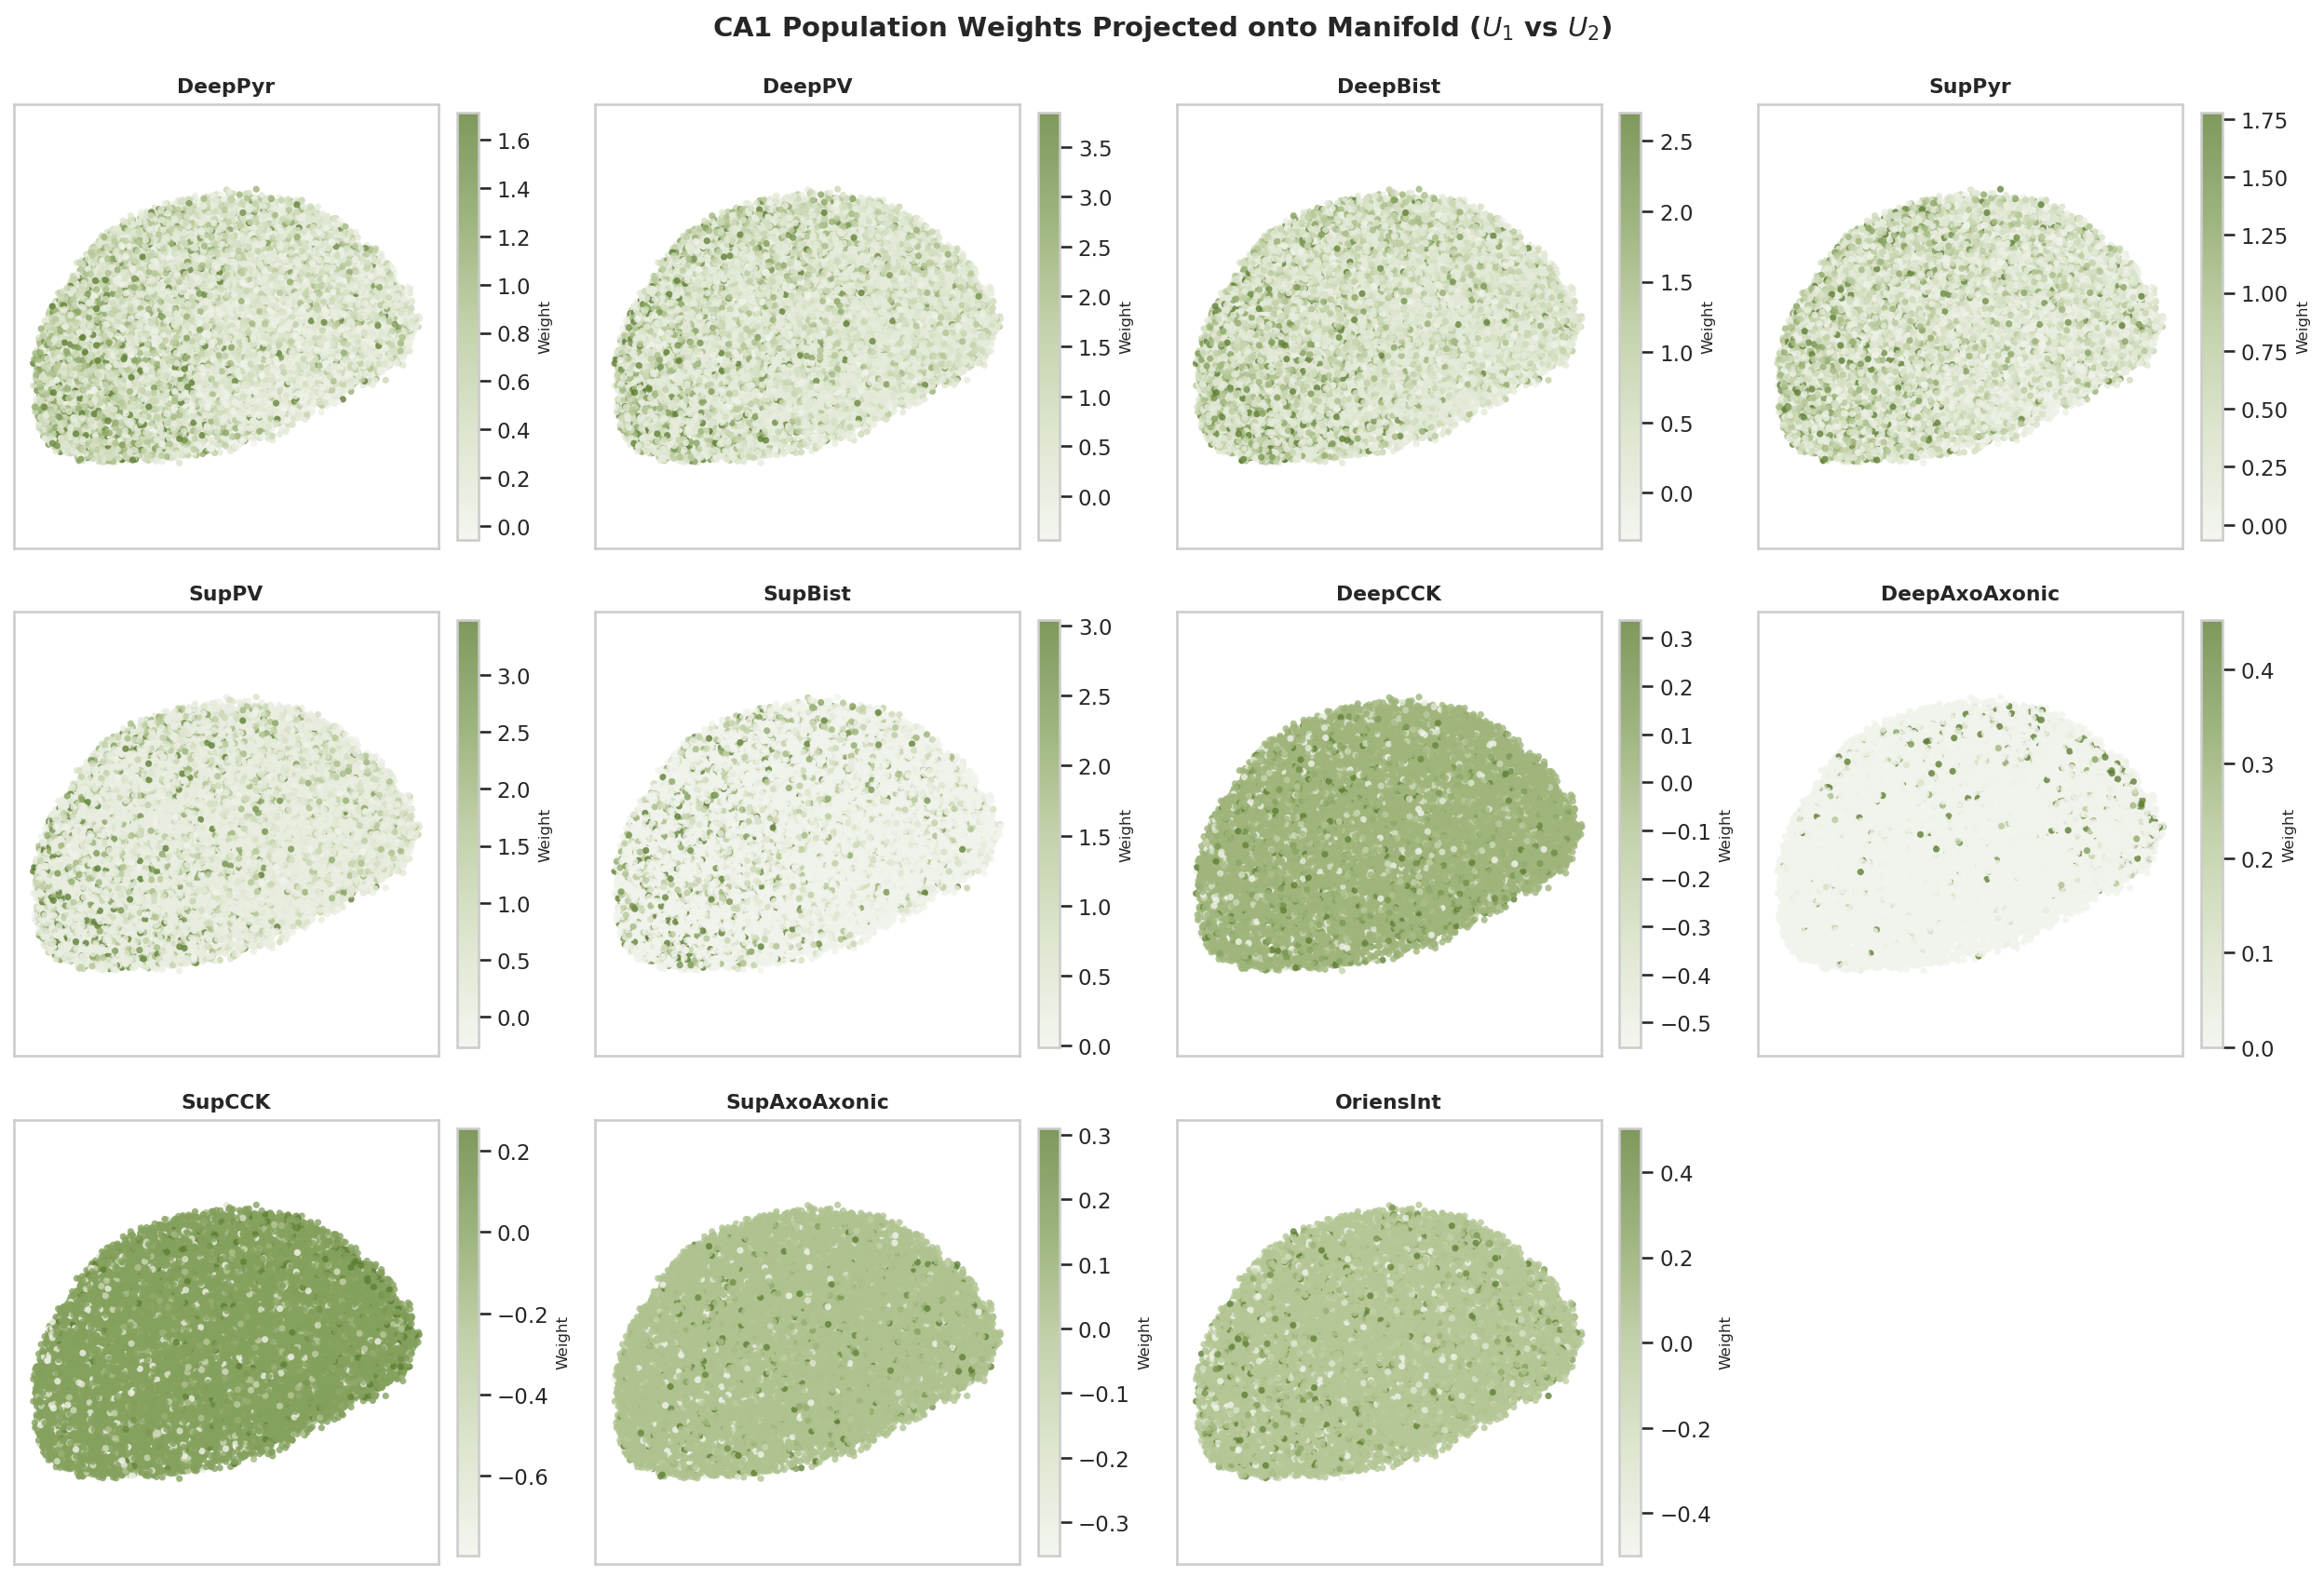

In [4]:
# ==============================================================================
# Cell 5: Latent Cloud Colored by 11 Cell-Type Weights
# ==============================================================================
n_cols = 4
n_rows = math.ceil(N_EXPERTS / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.8 * n_rows), dpi=150)
axes = axes.ravel()

# Combine train and test for cloud background
U_all_plot = np.vstack([U_train, U_test])
X_all_plot = np.vstack([X_train, X_test])

for i, name in enumerate(FULL_FEATS):
    ax = axes[i]
    w = X_all_plot[:, i]
    # Percentile clipping for clean contrast
    vmax = np.percentile(w, 98)
    vmin = np.percentile(w, 2)
    sc = ax.scatter(U_all_plot[:, 0], U_all_plot[:, 1], c=w, cmap=custom_green, s=12, vmin=vmin, vmax=vmax, alpha=0.8, linewidths=0)
    ax.set_title(name, fontweight="bold", fontsize=10.5)
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_xticks([]); ax.set_yticks([])
    
    cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Weight", fontsize=8)

for j in range(N_EXPERTS, len(axes)):
    axes[j].axis("off")

plt.suptitle("CA1 Population Weights Projected onto Manifold ($U_1$ vs $U_2$)", fontweight="bold", fontsize=14, y=0.99)
plt.tight_layout()
plt.show()

## Step 5: Geometry-Aware Density Gating ($g_j(\mathbf{u})$)

We evaluate the sharpened Gaussian density prior $g_j(\mathbf{u})$ fitted from `W_prior` and `U_prior`[cite: 3]:
$$g_j(\mathbf{u}) = \frac{Q_j(\mathbf{u})^\alpha}{\sum_k Q_k(\mathbf{u})^\alpha}, \qquad \alpha = 2.0$$
[cite: 3]
Each expert's gate concentrates in the region of the manifold corresponding to its subpopulation's firing center-of-mass[cite: 3].

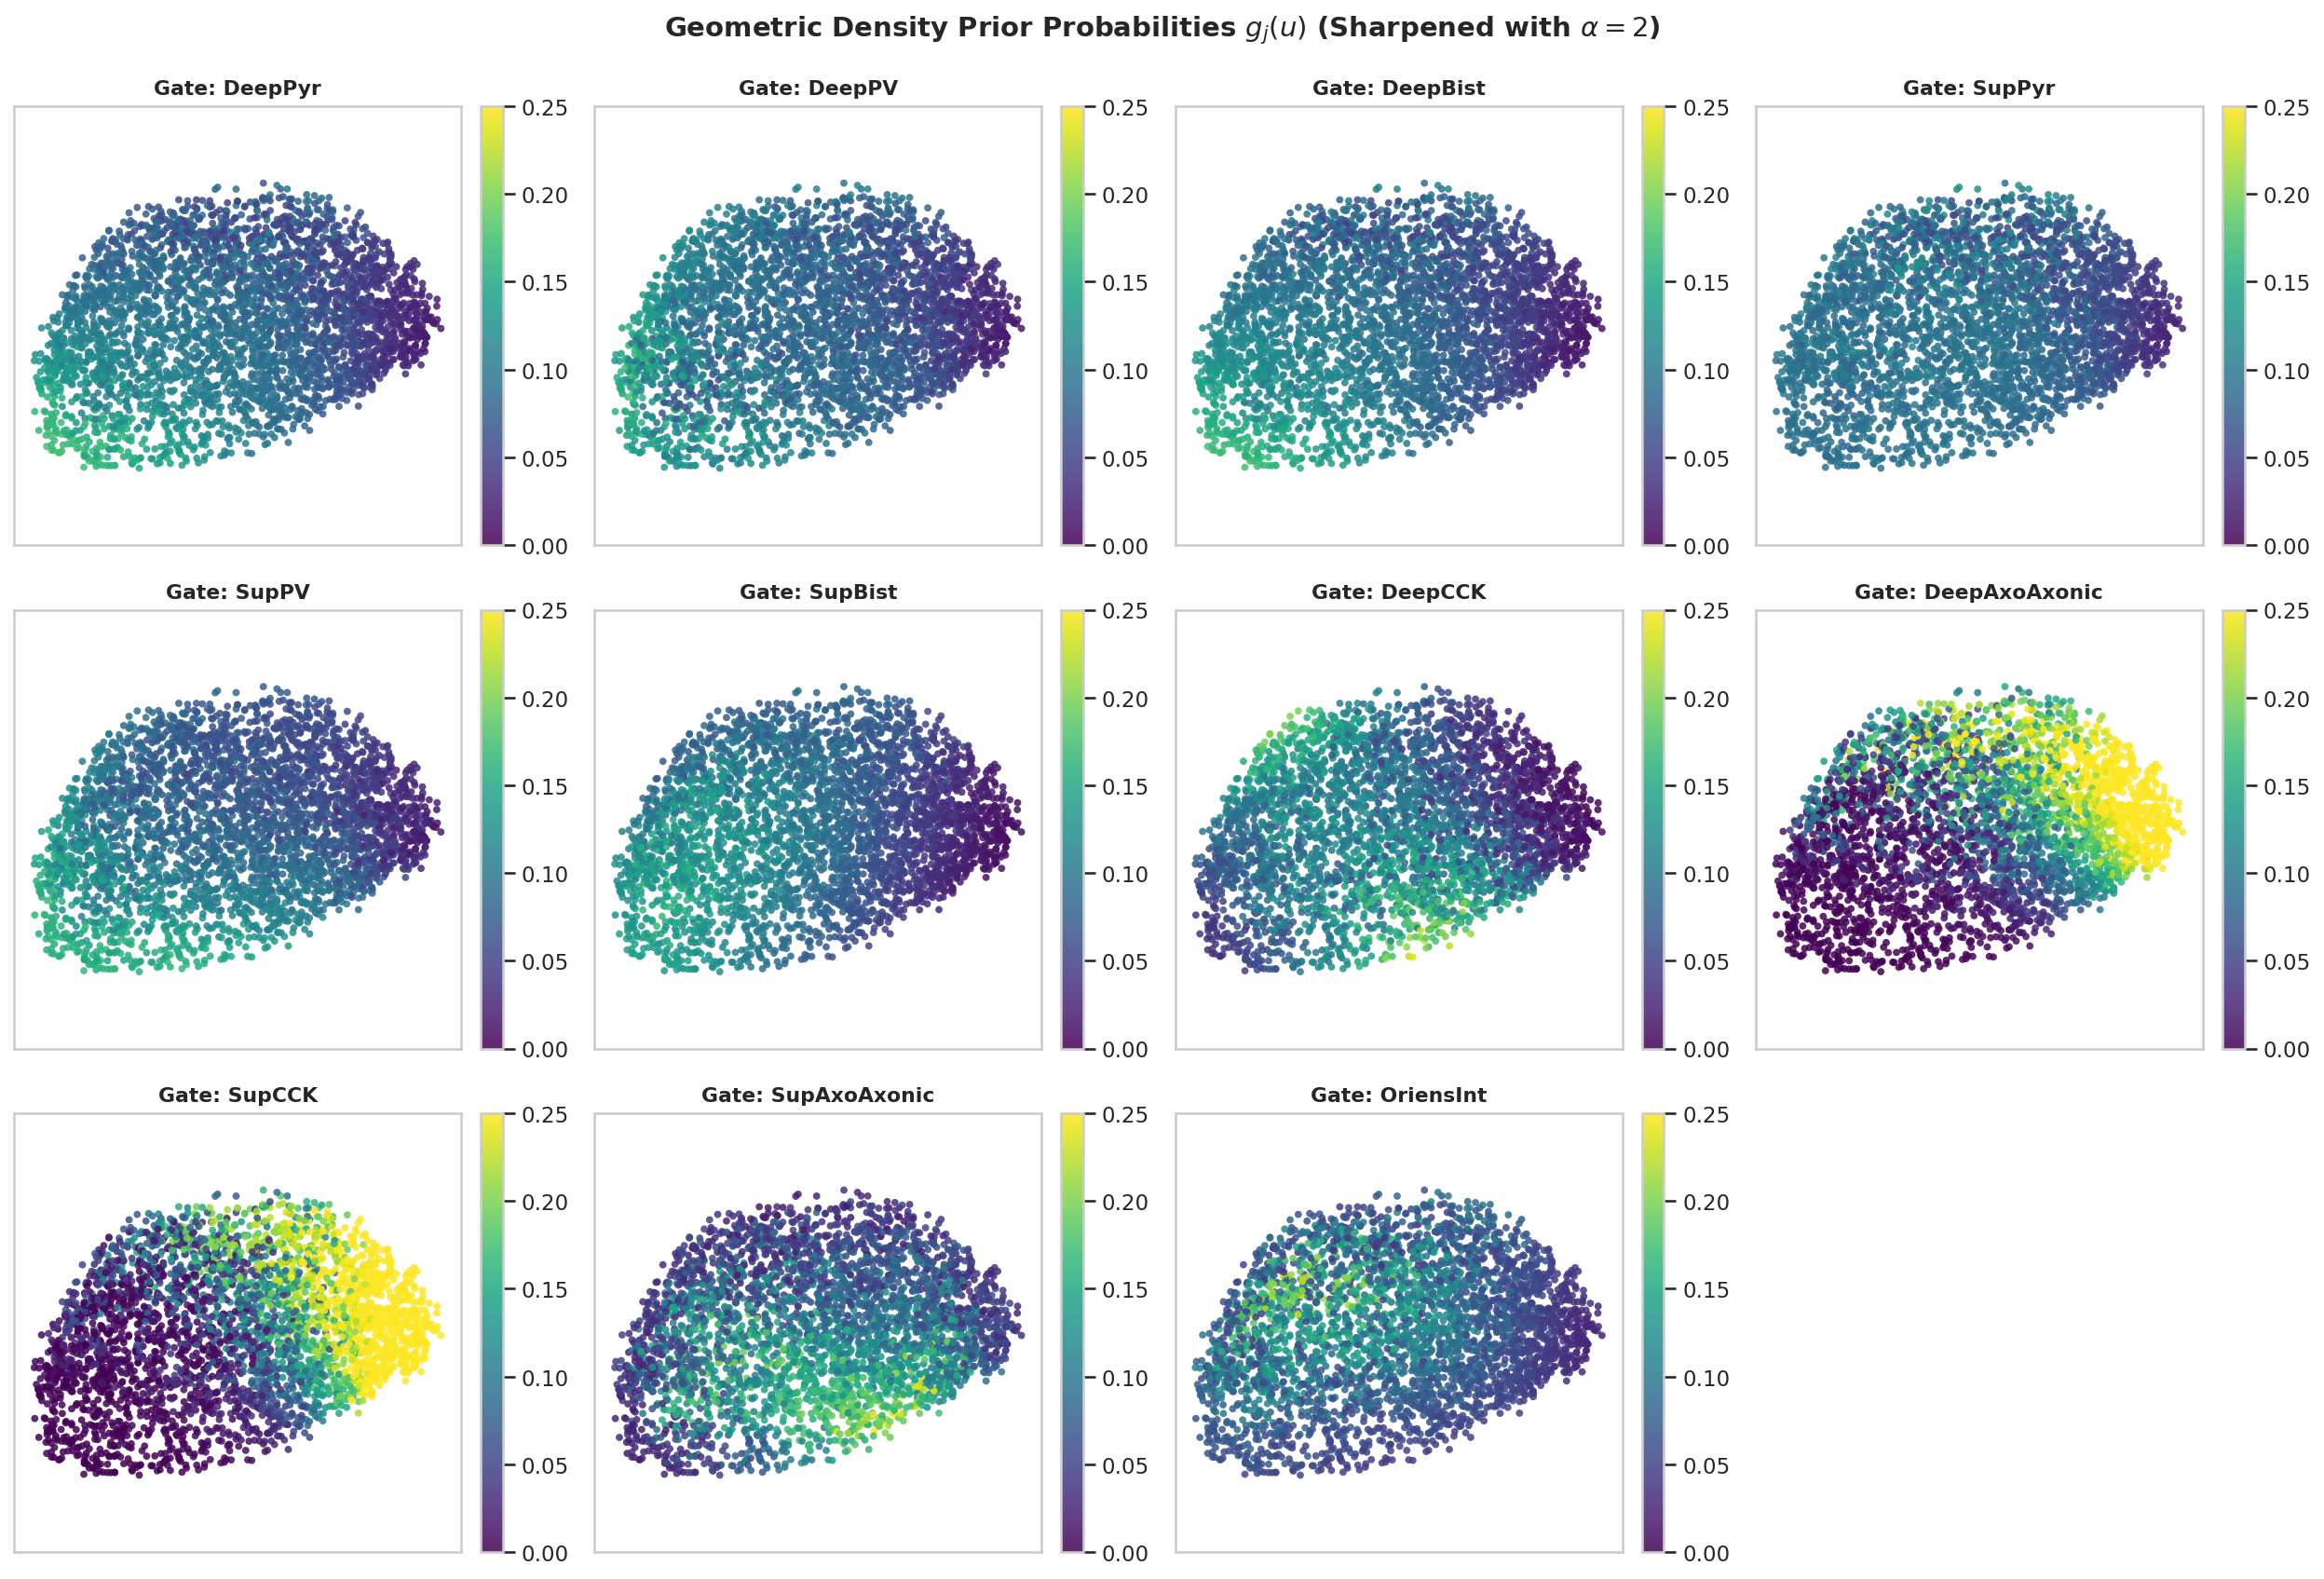

In [5]:
ALPHA_FUSION = 2
# ==============================================================================
# Cell 6: Fit Prior and Plot Density Gating Across the Manifold
# ==============================================================================
def fit_q_prior_model(U_ref, W_ref):
    comps = []
    n_feats = W_ref.shape[1]
    for j in range(n_feats):
        w = np.clip(W_ref[:, j], 0, None)
        s = w.sum() + 1e-12
        mu_j = (U_ref * w[:, None]).sum(0) / s
        diff = (U_ref - mu_j) * np.sqrt(w[:, None])
        C = (diff.T @ diff) / s + 1e-6 * np.eye(U_ref.shape[1])
        comps.append((mu_j, C))
        
    def evaluate_gates(U_eval, alpha=2.0):
        N_eval = U_eval.shape[0]
        Q = np.zeros((N_eval, n_feats))
        dim = U_eval.shape[1]
        for j, (m, C) in enumerate(comps):
            inv_C = np.linalg.inv(C)
            det_C = np.linalg.det(C)
            norm = 1.0 / np.sqrt(((2 * np.pi) ** dim) * det_C)
            diff = U_eval - m
            ex = np.einsum("ni,ij,nj->n", diff, inv_C, diff)
            Q[:, j] = norm * np.exp(-0.5 * ex)
        
        Q_sharp = (Q + 1e-12) ** alpha
        G = Q_sharp / Q_sharp.sum(axis=1, keepdims=True)
        return G
    return evaluate_gates

prior_fn = fit_q_prior_model(U_prior, W_prior)
G_train = prior_fn(U_train, alpha=ALPHA_FUSION)
G_test  = prior_fn(U_test, alpha=ALPHA_FUSION)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.8 * n_rows), dpi=150)
axes = axes.ravel()

for i, name in enumerate(FULL_FEATS):
    ax = axes[i]
    gate_val = G_test[:, i]
    sc = ax.scatter(U_test[:, 0], U_test[:, 1], c=gate_val, cmap="viridis", s=14, vmin=0, vmax=0.25, alpha=0.85, linewidths=0)
    ax.set_title(f"Gate: {name}", fontweight="bold", fontsize=10.5)
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

for j in range(N_EXPERTS, len(axes)):
    axes[j].axis("off")

plt.suptitle(f"Geometric Density Prior Probabilities $g_j(u)$ (Sharpened with $\\alpha={ALPHA_FUSION}$)", fontweight="bold", fontsize=14, y=0.99)
plt.tight_layout()
plt.show()

## Step 6: GaMoE Architecture & Joint Network Optimization

We train the 11 bottleneck experts $f_j(x_j)$ ($1 \to 11 \to \text{ReLU} \to 4$) using AdamW[cite: 3]. Gating probabilities $g_j(\mathbf{u})$ are fixed to the geometric density priors, ensuring each expert specializes in its manifold domain[cite: 3].

In [6]:
def corr_r2_scores(U_true, U_pred, eps=1e-12):
    U_true = np.asarray(U_true)
    U_pred = np.asarray(U_pred)
    D = U_true.shape[1]
    r_dims, r2_dims = [], []
    for d in range(D):
        x = U_true[:, d]
        y = U_pred[:, d]
        sx, sy = x.std(), y.std()
        if sx < eps or sy < eps:
            r = 0.0
        else:
            r = np.corrcoef(x, y)[0, 1]
            if np.isnan(r):
                r = 0.0
        r_dims.append(float(r))
        r2_dims.append(float(r**2))
    vars_ = U_true.var(axis=0)
    w = vars_ / (vars_.sum() + eps)
    r2_global = float((w * np.array(r2_dims)).sum())
    return r2_global, r2_dims, r_dims

HIDDEN_EXPERT = 11
LR = 0.001
WD = 0.0001
EPOCHS = 50
BATCH = 1024
PATIENCE = 25

# ==============================================================================
# Cell 7: Model Architecture & Training
# ==============================================================================
class ExpertLinearProj(nn.Module):
    def __init__(self, in_dim=1, out_dim=4, hidden=HIDDEN_EXPERT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden, bias=True),
            nn.ReLU(),
            nn.Linear(hidden, out_dim, bias=True),
        )
    def forward(self, x):
        return self.net(x)

class GatedMoE(nn.Module):
    def __init__(self, n_experts=11, out_dim=4, hidden=HIDDEN_EXPERT):
        super().__init__()
        self.n_experts = n_experts
        self.experts = nn.ModuleList([
            ExpertLinearProj(1, out_dim, hidden=hidden) for _ in range(n_experts)
        ])
    def forward(self, x, gates):
        outs = [exp(x[:, j:j+1]) for j, exp in enumerate(self.experts)]
        outs = torch.stack(outs, dim=2)  # [B, 4, N]
        y_mix = (outs * gates.unsqueeze(1)).sum(2)
        return y_mix, outs

# Standardize
scX = StandardScaler().fit(X_train)
scY = StandardScaler().fit(U_train)

Xt = torch.tensor(scX.transform(X_train), dtype=torch.float32, device=device)
Xv = torch.tensor(scX.transform(X_test),  dtype=torch.float32, device=device)
Yt = torch.tensor(scY.transform(U_train), dtype=torch.float32, device=device)
Yv = torch.tensor(scY.transform(U_test),  dtype=torch.float32, device=device)

Gt = torch.tensor(G_train, dtype=torch.float32, device=device)
Gv = torch.tensor(G_test,  dtype=torch.float32, device=device)

model = GatedMoE(n_experts=N_EXPERTS, out_dim=LATENT_DIM, hidden=HIDDEN_EXPERT).to(device)
opt   = optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
mse   = nn.MSELoss()

best_val, bad = np.inf, 0
print("Optimizing GaMoE...")

for ep in range(EPOCHS):
    model.train()
    idx = torch.randperm(Xt.size(0), device=device)
    for b in range(0, len(idx), BATCH):
        ib = idx[b:b+BATCH]
        y_hat, _ = model(Xt[ib], Gt[ib])
        loss = mse(y_hat, Yt[ib])
        opt.zero_grad()
        loss.backward()
        opt.step()

    model.eval()
    with torch.no_grad():
        yv_pred, _ = model(Xv, Gv)
        val = mse(yv_pred, Yv).item()
    if val < best_val:
        best_val, bad = val, 0
    else:
        bad += 1
    if bad >= PATIENCE:
        break

# Full model predictions on test set
model.eval()
with torch.no_grad():
    yv_scaled, expert_outs_scaled = model(Xv, Gv)
    y_pred_full = scY.inverse_transform(yv_scaled.cpu().numpy())
    
# Inverse transform individual expert outputs
expert_outs_np = expert_outs_scaled.cpu().numpy()  # [N_samples, 4, N_experts]
expert_outs_unscaled = np.zeros_like(expert_outs_np)
for j in range(N_EXPERTS):
    expert_outs_unscaled[:, :, j] = scY.inverse_transform(expert_outs_np[:, :, j])

r2_g, r2_d, _ = corr_r2_scores(U_test, y_pred_full)
print(f"Training Complete! Global R² on Held-out Test Set: {r2_g:.4f}")

Optimizing GaMoE...
Training Complete! Global R² on Held-out Test Set: 0.8138


## Step 7: Interactive Single-Ripple Expert Deconstruction

Use the slider below to select any ripple event $i$ from the test set. The tool displays:
* The ripple's true physical metrics: **Frequency** ($f$, Hz) and **Amplitude** ($a$, z-score).
* The **output vector of each independent expert** $f_j(w_j)$ plotted as distinct colored points on the manifold.
* The **gate probability** $g_j(\mathbf{u})$ displayed as an explicit percentage bar.
* The final **gated combination** $\hat{\mathbf{u}} = \sum_j g_j f_j$ compared to the true coordinate $\mathbf{u}$.

In [7]:
# ==============================================================================
# Cell 8: Interactive Expert Deconstruction Widget
# ==============================================================================
expert_palette = sns.color_palette("tab20", N_EXPERTS)

def inspect_single_ripple(ripple_idx):
    fig, (ax_u, ax_g) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1.3, 1]}, dpi=140)
    
    # Extract ripple features
    u_true_i = U_test[ripple_idx, :2]
    u_pred_i = y_pred_full[ripple_idx, :2]
    freq_i   = freq_test[ripple_idx]
    amp_i    = amp_test[ripple_idx]
    gates_i  = G_test[ripple_idx]
    
    # 1. Manifold Plot
    ax_u.scatter(U_test[:, 0], U_test[:, 1], c="#e0e0e0", s=10, alpha=0.5, label="Test Cloud")
    
    # Plot each expert's individual uncombined projection
    for j in range(N_EXPERTS):
        exp_proj = expert_outs_unscaled[ripple_idx, :2, j]
        ax_u.scatter(exp_proj[0], exp_proj[1], color=expert_palette[j], s=70, edgecolors="black", lw=0.7, zorder=5)
        # Line from expert projection to final gated prediction
        ax_u.plot([exp_proj[0], u_pred_i[0]], [exp_proj[1], u_pred_i[1]], color=expert_palette[j], lw=0.8, linestyle=":", alpha=0.6)
    
    # Plot final gated prediction and true point
    ax_u.scatter(u_pred_i[0], u_pred_i[1], marker="X", s=180, color="#1b4f72", edgecolors="black", lw=1.2, label=r"Combined $\hat{u}$", zorder=10)
    ax_u.scatter(u_true_i[0], u_true_i[1], marker="*", s=260, color="#d35400", edgecolors="black", lw=1.2, label="True $u$", zorder=11)
    
    error_i = np.linalg.norm(u_true_i - u_pred_i)
    ax_u.set_title(f"Ripple Event #{ripple_idx} | Error: {error_i:.3f}\nFreq: {freq_i:.1f} Hz | Amp: {amp_i:.2f} z", fontweight="bold", fontsize=11.5)
    ax_u.set_xlabel("UMAP 1", fontweight="bold")
    ax_u.set_ylabel("UMAP 2", fontweight="bold")
    ax_u.set_aspect("equal", adjustable="datalim")
    ax_u.legend(loc="upper right", frameon=True, fontsize=9)
    
    # 2. Gate Allocation Barplot
    y_pos = np.arange(N_EXPERTS)
    ax_g.barh(y_pos, gates_i * 100, color=expert_palette, edgecolor="black", height=0.65)
    ax_g.set_yticks(y_pos)
    ax_g.set_yticklabels(FULL_FEATS, fontsize=9.5, fontweight="bold")
    ax_g.set_xlabel("Gate Probability $g_j(u)$ (%)", fontweight="bold")
    ax_g.set_title(f"Gate Weight Distribution (Sharpened Prior)", fontweight="bold", fontsize=11.5)
    ax_g.set_xlim(0, max(30, np.max(gates_i * 100) * 1.25))
    ax_g.invert_yaxis()
    
    for i_bar, val in enumerate(gates_i):
        ax_g.text(val * 100 + 0.6, i_bar, f"{val*100:.1f}%", va="center", fontsize=8.5, fontweight="bold")
        
    plt.tight_layout()
    plt.show()

# Launch Slider
ripple_slider = widgets.IntSlider(
    value=15, min=0, max=len(U_test) - 1, step=1,
    description='Ripple ID:', continuous_update=False, layout=widgets.Layout(width='600px')
)

widgets.interact(inspect_single_ripple, ripple_idx=ripple_slider);

interactive(children=(IntSlider(value=15, continuous_update=False, description='Ripple ID:', layout=Layout(wid…

In [17]:
# ==============================================================================
# Cell: Interactive Manifold Deconstruction (Before Ablations)
# ==============================================================================
import ipywidgets as widgets
from IPython.display import display
from scipy.spatial import cKDTree

# 1. Build spatial tree for instantaneous neighbor snapping
umap_tree = cKDTree(U_test[:, :2])
expert_palette = sns.color_palette("tab20", N_EXPERTS)

# 2. Interactive Coordinate & Color Widgets (No Ablation Dependencies)
u1_min, u1_max = float(U_test[:, 0].min()), float(U_test[:, 0].max())
u2_min, u2_max = float(U_test[:, 1].min()), float(U_test[:, 1].max())

u1_slider = widgets.FloatSlider(
    value=float(U_test[0, 0]), min=u1_min, max=u1_max, step=0.05,
    description='Target UMAP 1:', continuous_update=False, layout=widgets.Layout(width='380px')
)
u2_slider = widgets.FloatSlider(
    value=float(U_test[0, 1]), min=u2_min, max=u2_max, step=0.05,
    description='Target UMAP 2:', continuous_update=False, layout=widgets.Layout(width='380px')
)

color_toggle = widgets.ToggleButtons(
    options=["Frequency", "Amplitude"],
    value="Frequency",
    description="Color Cloud:",
    button_style="info"
)

out_dashboard = widgets.Output()

# 3. Main Dashboard Rendering Function
def render_manifold_deconstruction(u1_coord, u2_coord, color_by):
    # Query nearest test ripple to the crosshair coordinates
    dist, nearest_idx = umap_tree.query([u1_coord, u2_coord])
    idx = int(nearest_idx)
    
    with out_dashboard:
        out_dashboard.clear_output(wait=True)
        
        fig = plt.figure(figsize=(19, 6), dpi=130)
        gs = fig.add_gridspec(1, 3, width_ratios=[1.1, 1.25, 0.85])
        
        # ----------------------------------------------------------------------
        # Panel 1: Manifold Navigation & Snapped Ripple Position
        # ----------------------------------------------------------------------
        ax_map = fig.add_subplot(gs[0, 0])
        c_vals = freq_test if color_by == "Frequency" else amp_test
        c_lbl = "Frequency (Hz)" if color_by == "Frequency" else "Amplitude (z)"
        c_map = "coolwarm" if color_by == "Frequency" else "magma"
        
        sc = ax_map.scatter(U_test[:, 0], U_test[:, 1], c=c_vals, cmap=c_map, s=14, alpha=0.45, linewidths=0)
        cbar = fig.colorbar(sc, ax=ax_map, fraction=0.046, pad=0.04)
        cbar.set_label(c_lbl, fontweight="bold", fontsize=9)
        
        # Crosshair lines and highlight markers
        ax_map.axvline(u1_coord, color="gray", linestyle=":", lw=1.0, alpha=0.6)
        ax_map.axhline(u2_coord, color="gray", linestyle=":", lw=1.0, alpha=0.6)
        ax_map.scatter(U_test[idx, 0], U_test[idx, 1], marker="o", s=140, facecolors="none", edgecolors="black", lw=2, zorder=10)
        ax_map.scatter(U_test[idx, 0], U_test[idx, 1], marker="*", s=170, color="#f1c40f", edgecolors="black", lw=0.8, zorder=11, label=f"Snapped Event #{idx}")
        
        ax_map.set_title(f"Manifold Location Navigator\nNearest Event #{idx} (Snap dist: {dist:.3f})", fontweight="bold", fontsize=11)
        ax_map.set_xlabel("UMAP 1", fontweight="bold")
        ax_map.set_ylabel("UMAP 2", fontweight="bold")
        ax_map.set_aspect("equal", adjustable="datalim")
        ax_map.legend(loc="upper right", frameon=True, fontsize=8.5)
        
        # ----------------------------------------------------------------------
        # Panel 2: Deconstructed Expert Projections & Gated Prediction
        # ----------------------------------------------------------------------
        ax_dec = fig.add_subplot(gs[0, 1])
        ax_dec.scatter(U_test[:, 0], U_test[:, 1], c="#e2e8f0", s=8, alpha=0.4, label="Test Cloud")
        
        u_true = U_test[idx, :2]
        u_pred_full = y_pred_full[idx, :2]
        f_val = freq_test[idx]
        a_val = amp_test[idx]
        gates_i = G_test[idx]
        
        # Plot individual expert projections f_j(x_j)
        for j in range(N_EXPERTS):
            exp_xy = expert_outs_unscaled[idx, :2, j]
            ax_dec.scatter(exp_xy[0], exp_xy[1], color=expert_palette[j], s=60, edgecolors="black", lw=0.6, zorder=5)
            ax_dec.plot([exp_xy[0], u_pred_full[0]], [exp_xy[1], u_pred_full[1]], color=expert_palette[j], lw=0.8, linestyle=":", alpha=0.55)
            
        err_full = np.linalg.norm(u_true - u_pred_full)
        ax_dec.scatter(u_true[0], u_true[1], marker="*", s=260, color="#f1c40f", edgecolors="black", lw=1.2, label=f"True u", zorder=12)
        ax_dec.scatter(u_pred_full[0], u_pred_full[1], marker="o", s=110, color="#1b4f72", edgecolors="white", lw=1.0, label=f"Combined (Err: {err_full:.2f})", zorder=11)
        
        ax_dec.set_title(f"Event #{idx} Deconstruction\nFreq: {f_val:.1f} Hz | Amp: {a_val:.2f} z", fontweight="bold", fontsize=11)
        ax_dec.set_xlabel("UMAP 1", fontweight="bold")
        ax_dec.set_ylabel("UMAP 2", fontweight="bold")
        ax_dec.set_aspect("equal", adjustable="datalim")
        ax_dec.legend(loc="upper right", frameon=True, fontsize=8.5)
        
        # ----------------------------------------------------------------------
        # Panel 3: Gating Allocation
        # ----------------------------------------------------------------------
        ax_g = fig.add_subplot(gs[0, 2])
        y_pos = np.arange(N_EXPERTS)
        ax_g.barh(y_pos, gates_i * 100, color=expert_palette, edgecolor="black", height=0.65)
        ax_g.set_yticks(y_pos)
        ax_g.set_yticklabels(FULL_FEATS, fontsize=8.5, fontweight="bold")
        ax_g.set_xlabel("Gate Probability $g_j(u)$ (%)", fontweight="bold")
        ax_g.set_title("Expert Gate Allocation ($g_j$)", fontweight="bold", fontsize=11)
        ax_g.set_xlim(0, max(25, np.max(gates_i * 100) * 1.3))
        ax_g.invert_yaxis()
        
        for k_b, val in enumerate(gates_i):
            ax_g.text(val * 100 + 0.5, k_b, f"{val*100:.1f}%", va="center", fontsize=8, fontweight="bold")
            
        plt.tight_layout()
        plt.show()

# 4. Observer Callback
def on_slider_change(change):
    render_manifold_deconstruction(u1_slider.value, u2_slider.value, color_toggle.value)

u1_slider.observe(on_slider_change, names='value')
u2_slider.observe(on_slider_change, names='value')
color_toggle.observe(on_slider_change, names='value')

# 5. Display Widget Layout
controls_row1 = widgets.HBox([u1_slider, u2_slider])
controls_row2 = widgets.HBox([color_toggle])
display(widgets.VBox([controls_row1, controls_row2, out_dashboard]))

# Initial render
render_manifold_deconstruction(u1_slider.value, u2_slider.value, color_toggle.value)

## Step 8: Interactive Single-Ripple Ablation Impact Simulator

This interactive tool allows you to:
1. Select a **Ripple ID**.
2. Select any **Ablation Condition** (`All`, `No_PC`, `No_PV`, `No_CCK`, `No_Mod1`, `No_Mod2`, etc.)[cite: 3].
3. Choose the **Ablation Mode**:
   * `gate`: Gate Masking (zeros selected gates and renormalizes)[cite: 3].
   * `shuffle`: Gate Shuffling (destroys coordinate alignment)[cite: 3].
4. Color-code the background manifold by **Frequency** or **Amplitude**.
5. Observe in real time the resulting vector shift $\mathbf{u}_{\text{true}} \to \hat{\mathbf{u}}_{\text{ablated}}$ and the exact numerical displacement error.

In [15]:
# ==============================================================================
# Cell 9: Interactive Manifold Navigation (Sliders or Click) + Ablation Simulator
# ==============================================================================
import re
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import display
from scipy.spatial import cKDTree

# ------------------------------------------------------------------------------
# 1. Self-Contained Definition of Ablation Hierarchy & Constants
# ------------------------------------------------------------------------------
feat_to_idx = {f: i for i, f in enumerate(FULL_FEATS)}
n_experts = len(FULL_FEATS)

CELLTYPE_PAIRS = {
    "Pyr":       ["DeepPyr", "SupPyr"],
    "PV":        ["DeepPV", "SupPV"],
    "Bist":      ["DeepBist", "SupBist"],
    "CCK":       ["DeepCCK", "SupCCK"],
    "AxoAxonic": ["DeepAxoAxonic", "SupAxoAxonic"],
    "OriensInt": ["OriensInt"],
}

CELLTYPES_WITH_DEPTH = ["Pyr", "PV", "Bist", "CCK", "AxoAxonic"]

# Base conditions
ABLATION_CONDS = {
    "All":          [],
    "No_Int":       [f for f in FULL_FEATS if f not in CELLTYPE_PAIRS["Pyr"]],
    "No_Pyr":       CELLTYPE_PAIRS["Pyr"],
    "No_PV":        CELLTYPE_PAIRS["PV"],
    "No_Bist":      CELLTYPE_PAIRS["Bist"],
    "No_CCK":       CELLTYPE_PAIRS["CCK"],
    "No_AxoAxonic": CELLTYPE_PAIRS["AxoAxonic"],
    "No_OriensInt": CELLTYPE_PAIRS["OriensInt"],
}

# Add depth-specific conditions (deep vs sup)
for ct in CELLTYPES_WITH_DEPTH:
    deep_feat, sup_feat = CELLTYPE_PAIRS[ct]
    ABLATION_CONDS[f"No_{ct}_deep"] = [deep_feat]
    ABLATION_CONDS[f"No_{ct}_sup"]  = [sup_feat]

DEEPPYR = ["SupPyr", "DeepPV", "DeepBist", "DeepCCK", "DeepAxoAxonic", "OriensInt", "SupPV", "SupBist", "SupCCK", "SupAxoAxonic"]
SUPPYR  = ["DeepPyr", "DeepPV", "DeepBist", "DeepCCK", "DeepAxoAxonic", "OriensInt", "SupPV", "SupBist", "SupCCK", "SupAxoAxonic"]

ABLATION_CONDS["No_Int_deep"] = DEEPPYR
ABLATION_CONDS["No_Int_sup"]  = SUPPYR

# ------------------------------------------------------------------------------
# 2. Coordinate Search Tree & Widget Setup
# ------------------------------------------------------------------------------
umap_tree = cKDTree(U_test[:, :2])

u1_min, u1_max = float(U_test[:, 0].min()), float(U_test[:, 0].max())
u2_min, u2_max = float(U_test[:, 1].min()), float(U_test[:, 1].max())

# Coordinate Sliders for each UMAP direction
u1_slider = widgets.FloatSlider(
    value=float(U_test[0, 0]), min=u1_min, max=u1_max, step=0.05,
    description='UMAP 1:', continuous_update=False,
    layout=widgets.Layout(width='45%')
)
u2_slider = widgets.FloatSlider(
    value=float(U_test[0, 1]), min=u2_min, max=u2_max, step=0.05,
    description='UMAP 2:', continuous_update=False,
    layout=widgets.Layout(width='45%')
)

color_widget = widgets.ToggleButtons(
    options=["Frequency", "Amplitude"],
    value="Frequency",
    description="Color Cloud By:",
    button_style="info"
)

cond_widget = widgets.Dropdown(
    options=list(ABLATION_CONDS.keys()),
    value="No_PV",
    description="Ablation:",
    layout=widgets.Layout(width="280px")
)

mode_widget = widgets.RadioButtons(
    options=["gate", "shuffle"],
    value="gate",
    description="Mode:",
    layout=widgets.Layout(width="180px")
)

out_dashboard = widgets.Output(layout=widgets.Layout(width='100%', overflow='hidden'))

# ------------------------------------------------------------------------------
# 3. Main Dashboard Rendering by Target Coordinates
# ------------------------------------------------------------------------------
def render_manifold_ablation(target_u1, target_u2, condition, mode, color_by):
    # Snap to nearest real ripple in test set
    dist, nearest_idx = umap_tree.query([target_u1, target_u2])
    idx = int(nearest_idx)
    
    with out_dashboard:
        out_dashboard.clear_output(wait=True)
        
        # Dimensions adjusted to fit 100% of cell width without horizontal scrollbars
        fig, (ax_map, ax_zoom) = plt.subplots(1, 2, figsize=(14, 5.8), dpi=110)
        
        # Background coloring
        c_vals = freq_test if color_by == "Frequency" else amp_test
        c_label = "Frequency (Hz)" if color_by == "Frequency" else "Amplitude (z-score)"
        cmap_bg = "coolwarm" if color_by == "Frequency" else "magma"
        
        # Panel 1: Full Manifold Cloud with Crosshair & Target Indicators
        sc = ax_map.scatter(U_test[:, 0], U_test[:, 1], c=c_vals, cmap=cmap_bg, s=14, alpha=0.45, linewidths=0)
        cbar = fig.colorbar(sc, ax=ax_map, fraction=0.046, pad=0.04)
        cbar.set_label(c_label, fontweight="bold", fontsize=9)
        
        # Slider Crosshair lines
        ax_map.axvline(target_u1, color="gray", linestyle=":", lw=1.0, alpha=0.6)
        ax_map.axhline(target_u2, color="gray", linestyle=":", lw=1.0, alpha=0.6)
        
        # Snapped Event Indicators
        ax_map.scatter(U_test[idx, 0], U_test[idx, 1], marker="o", s=130, facecolors="none", edgecolors="black", lw=2, zorder=10)
        ax_map.scatter(U_test[idx, 0], U_test[idx, 1], marker="*", s=170, color="#f1c40f", edgecolors="black", lw=0.8, zorder=11, label=f"Snapped Event #{idx}")
        
        ax_map.set_title(f"Manifold Navigation (Click cloud or move sliders)\nNearest Event #{idx} (Snap dist: {dist:.3f})", fontweight="bold", fontsize=11)
        ax_map.set_xlabel("UMAP 1", fontweight="bold")
        ax_map.set_ylabel("UMAP 2", fontweight="bold")
        ax_map.set_aspect("equal", adjustable="datalim")
        ax_map.legend(loc="upper right", frameon=True, fontsize=8.5)
        
        # Panel 2: Ablation Displacement & Reconstruction Failure
        u_true_i = U_test[idx, :2]
        freq_i = freq_test[idx]
        amp_i  = amp_test[idx]
        u_pred_full = y_pred_full[idx, :2]
        
        # Apply ablation on selected event
        drop_list = ABLATION_CONDS[condition]
        drop_indices = [feat_to_idx[f] for f in drop_list]
        
        G_mod = Gv[idx:idx+1].clone()
        if mode == "gate":
            for d in drop_indices:
                G_mod[0, d] = 0.0
        elif mode == "shuffle":
            if len(drop_indices) > 0:
                perm = torch.randperm(Gv.size(0), device=device)
                for d in drop_indices:
                    G_mod[0, d] = Gv[perm[0], d]
                    
        G_mod /= (G_mod.sum(dim=1, keepdim=True) + 1e-12)
        
        model.eval()
        with torch.no_grad():
            y_abl_scaled, _ = model(Xv[idx:idx+1], G_mod)
            u_pred_abl = scY.inverse_transform(y_abl_scaled.cpu().numpy())[0, :2]
            
        err_full = np.linalg.norm(u_true_i - u_pred_full)
        err_abl  = np.linalg.norm(u_true_i - u_pred_abl)
        shift    = np.linalg.norm(u_pred_full - u_pred_abl)
        
        ax_zoom.scatter(U_test[:, 0], U_test[:, 1], c="#e2e8f0", s=8, alpha=0.4, label="Test Cloud")
        ax_zoom.scatter(u_true_i[0], u_true_i[1], marker="*", s=260, color="#f1c40f", edgecolors="black", lw=1.2, zorder=12, label="True Event")
        ax_zoom.scatter(u_pred_full[0], u_pred_full[1], marker="o", s=110, color="#1b4f72", edgecolors="white", lw=1.0, zorder=11, label=f"Full Model (Err: {err_full:.2f})")
        ax_zoom.scatter(u_pred_abl[0], u_pred_abl[1], marker="X", s=130, color="#c0392b", edgecolors="black", lw=1.0, zorder=11, label=f"Ablated: {condition} (Err: {err_abl:.2f})")
        
        # Red displacement arrow
        ax_zoom.annotate("", xy=(u_pred_abl[0], u_pred_abl[1]), xytext=(u_pred_full[0], u_pred_full[1]),
                         arrowprops=dict(arrowstyle="->", lw=2.0, color="#c0392b", mutation_scale=14))
        
        ax_zoom.set_title(f"Ablation Impact (Shift: {shift:.3f})\nFreq: {freq_i:.1f} Hz | Amp: {amp_i:.2f} z", fontweight="bold", fontsize=11)
        ax_zoom.set_xlabel("UMAP 1", fontweight="bold")
        ax_zoom.set_ylabel("UMAP 2", fontweight="bold")
        ax_zoom.set_aspect("equal", adjustable="datalim")
        ax_zoom.legend(loc="upper right", frameon=True, fontsize=8.5)
        
        plt.tight_layout()
        
        # Optional canvas click handler (if interactive backend is active)
        def onclick(event):
            if event.inaxes == ax_map and event.xdata is not None and event.ydata is not None:
                u1_slider.value = float(event.xdata)
                u2_slider.value = float(event.ydata)
                
        fig.canvas.mpl_connect('button_press_event', onclick)
        plt.show()

# ------------------------------------------------------------------------------
# 4. Observer Callbacks & Layout
# ------------------------------------------------------------------------------
def on_param_change(change):
    render_manifold_ablation(
        u1_slider.value, u2_slider.value,
        cond_widget.value, mode_widget.value, color_widget.value
    )

u1_slider.observe(on_param_change, names="value")
u2_slider.observe(on_param_change, names="value")
cond_widget.observe(on_param_change, names="value")
mode_widget.observe(on_param_change, names="value")
color_widget.observe(on_param_change, names="value")

# Assembly of the clean controls layout
row_sliders  = widgets.HBox([u1_slider, u2_slider], layout=widgets.Layout(width='100%', justify_content='space-between'))
row_controls = widgets.HBox([color_widget, cond_widget, mode_widget], layout=widgets.Layout(align_items='center', margin='8px 0 8px 0'))
ui_container = widgets.VBox([row_sliders, row_controls, out_dashboard], layout=widgets.Layout(width='100%'))

display(ui_container)

# Initial render
render_manifold_ablation(u1_slider.value, u2_slider.value, cond_widget.value, mode_widget.value, color_widget.value)

## Step 9: Statistical Summary of Depth-Resolved Ablations

Finally, we parse the 10-fold metric records and summarize the ANOVA effects of cell type and laminar depth (`deep` vs `sup`)[cite: 3].

In [16]:
# ==============================================================================
# Cell 10: Statistical Metrics Table for Fold 1
# ==============================================================================
records = []
for cond_name in ABLATION_CONDS.keys():
    for m in ["gate", "shuffle"]:
        mask_c = (df_metrics["feature_set"] == cond_name) & (df_metrics["ablation_mode"] == m)
        if mask_c.sum() > 0:
            sub = df_metrics[mask_c]
            records.append({
                "Condition": cond_name,
                "Mode": m,
                "R2_global (Mean ± SD)": f"{sub['R2_global'].mean():.3f} ± {sub['R2_global'].std():.3f}",
                "RMSE (Mean ± SD)": f"{sub['RMSE'].mean():.3f} ± {sub['RMSE'].std():.3f}",
            })

df_summary_table = pd.DataFrame(records)
print("Ablation Benchmark Table Across All Folds:")
display(df_summary_table.head(15))

NameError: name 'df_metrics' is not defined